In [1]:
import os
import gzip
import shutil
import urllib.request
from collections import defaultdict
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, cdist, squareform

# configurações globais de visualização
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

# pastas de saída
os.makedirs('genomas',    exist_ok=True)
os.makedirs('resultados', exist_ok=True)

print('imports ok')

imports ok


# **Frequency Chaos Game Representation (fCGR)**

Nesta primeira etapa do código, mapeei as assinaturas genômicas de todos os 8 organismos do dataset em formato de imagem, utilizando a técnica fCGR (Frequency Chaos Game Representation).O script inicia iterando sobre os arquivos CSV gerados no pré-processamento. Para cada organismo, ele lê as frequências dos k-mers canônicos e as distribui em uma matriz bidimensional ($2^k \times 2^k$), onde cada quadrante representa uma base nitrogenada (C, G, A, T). Como utilizei contagens canônicas para otimização, implementei uma função que divide a frequência igualmente entre o k-mer e seu reverso complementar, garantindo a reconstrução completa e simétrica da imagem.Para permitir uma análise comparativa, configurei o código para gerar um painel com um grid retangular ($2 \times 4$), exibindo os 8 organismos lado a lado. Adicionei aos títulos das imagens os metadados de Domínio e Ambiente de cada genoma. Coloquei tudo isso dentro de um loop que processa automaticamente os 3 tamanhos de fragmento e os 8 valores de $k$, exportando as dezenas de imagens geradas diretamente para a pasta resultados/fcgr_imagens_todos/.

In [2]:
# Configurações de plotagem
plt.rcParams['figure.dpi'] = 120
sns.set_style("white")

# Criação da subpasta para organizar as imagens fCGR
pasta_fcgr = 'resultados/fcgr_imagens_todos'
os.makedirs(pasta_fcgr, exist_ok=True)
print(f"Pasta para imagens criada/verificada: {pasta_fcgr}/")

# 1. Funções Auxiliares para o fCGR
RC = str.maketrans('ATGC', 'TACG')
def rev_comp(seq):
    return seq.translate(RC)[::-1]

def get_fcgr_coordinates(kmer):
    k = len(kmer)
    min_row, max_row = 0, 2**k
    min_col, max_col = 0, 2**k

    for char in kmer:
        mid_row = (min_row + max_row) // 2
        mid_col = (min_col + max_col) // 2
        if char == 'C':
            max_row, max_col = mid_row, mid_col
        elif char == 'G':
            max_row, min_col = mid_row, mid_col
        elif char == 'A':
            min_row, max_col = mid_row, mid_col
        elif char == 'T':
            min_row, min_col = mid_row, mid_col

    return min_row, min_col

def generate_fcgr_matrix(kmer_counts, k):
    matrix_size = 2**k
    fcgr_matrix = np.zeros((matrix_size, matrix_size))

    for kmer, count in kmer_counts.items():
        if count == 0: continue
        rc_kmer = rev_comp(kmer)
        half_count = count / 2.0

        r1, c1 = get_fcgr_coordinates(kmer)
        fcgr_matrix[r1, c1] += half_count

        r2, c2 = get_fcgr_coordinates(rc_kmer)
        fcgr_matrix[r2, c2] += half_count

    return fcgr_matrix

# 2. Definição dos loops para Tamanho de Fragmento e valores de k
tamanhos_frag = ["500kbp", "1000kbp", "1500kbp"]
valores_k = [1, 2, 3, 4, 5, 6, 7, 8]

for TAMANHO in tamanhos_frag:
    print(f"\n{'='*50}\nPROCESSANDO FRAGMENTOS DE {TAMANHO}\n{'='*50}")

    for K_VALUE in valores_k:
        csv_path = f'resultados/vetores_frag{TAMANHO}_k{K_VALUE}.csv'

        if not os.path.exists(csv_path):
            continue

        print(f"\n--- Gerando fCGR para {TAMANHO} | k={K_VALUE} ---")
        df = pd.read_csv(csv_path)
        kmer_columns = df.columns[3:]

        # 3. Geração das Matrizes fCGR para TODOS os organismos
        fcgr_matrices = {}
        todos_organismos = df['organismo'].tolist()

        for index, row in df.iterrows():
            org_name = row['organismo']
            counts = row[kmer_columns].to_dict()
            mat = generate_fcgr_matrix(counts, K_VALUE)
            total_sum = np.sum(mat)
            mat_normalized = mat / total_sum if total_sum > 0 else mat
            fcgr_matrices[org_name] = mat_normalized

        # 4. Plotagem para os 8 Organismos (Grid 2x4)
        # Ajustamos o tamanho da figura para ficar mais larga e acomodar as 4 colunas
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        fig.suptitle(f'fCGR (k={K_VALUE} | Frag: {TAMANHO})\nAssinatura Genômica (Domínio e Ambiente)', fontsize=20, y=0.98)
        axes = axes.flatten()

        for i, org in enumerate(todos_organismos):
            ax = axes[i]
            mat = fcgr_matrices[org]

            # Pegando os metadados
            meta = df[df['organismo'] == org].iloc[0]
            domain = meta['dominio']
            ambiente = meta['ambiente']

            im = ax.imshow(mat, cmap='GnBu', interpolation='nearest')

            # Ajuste dinâmico da posição das letras C, G, A, T
            max_coord = (2**K_VALUE)
            offset = max(0.5, max_coord * 0.03)

            ax.text(-offset, -offset, 'C', fontsize=12, fontweight='bold', ha='right', va='bottom')
            ax.text(max_coord - 1 + offset, -offset, 'G', fontsize=12, fontweight='bold', ha='left', va='bottom')
            ax.text(-offset, max_coord - 1 + offset, 'A', fontsize=12, fontweight='bold', ha='right', va='top')
            ax.text(max_coord - 1 + offset, max_coord - 1 + offset, 'T', fontsize=12, fontweight='bold', ha='left', va='top')

            # Título atualizado com nome, domínio e ambiente
            ax.set_title(f"{org}\n({domain} - {ambiente})", fontsize=12, fontweight='bold')
            ax.axis('off')

        # Ajuste da barra de cores para o grid 2x4
        cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
        fig.colorbar(im, cax=cbar_ax, label=f'Frequência Normalizada do {K_VALUE}-mer')

        plt.subplots_adjust(wspace=0.15, hspace=0.25)

        save_path = f'{pasta_fcgr}/fcgr_todos_frag{TAMANHO}_k{K_VALUE}.png'
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close(fig)
        print(f"Salvo: {save_path}")

print("\nProcessamento visual concluído! Verifique a pasta 'resultados/fcgr_imagens_todos/'.")

Pasta para imagens criada/verificada: resultados/fcgr_imagens_todos/

PROCESSANDO FRAGMENTOS DE 500kbp

--- Gerando fCGR para 500kbp | k=1 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k1.png

--- Gerando fCGR para 500kbp | k=2 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k2.png

--- Gerando fCGR para 500kbp | k=3 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k3.png

--- Gerando fCGR para 500kbp | k=4 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k4.png

--- Gerando fCGR para 500kbp | k=5 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k5.png

--- Gerando fCGR para 500kbp | k=6 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k6.png

--- Gerando fCGR para 500kbp | k=7 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k7.png

--- Gerando fCGR para 500kbp | k=8 ---
Salvo: resultados/fcgr_imagens_todos/fcgr_todos_frag500kbp_k8.png

PROCESSANDO FRAGMENTOS DE 1000kbp

--- Gerando f

Na segunda etapa, implementei a validação matemática daquilo que as imagens do fCGR me mostraram visualmente. O objetivo aqui foi descobrir qual combinação exata de tamanho de fragmento e valor de $k$ capturou melhor essa anomalia da convergência evolutiva.O código lê novamente os vetores de k-mers, os normaliza como frequências relativas e utiliza a biblioteca scipy para calcular a Distância Euclidiana entre todos os 8 organismos. Para automatizar a identificação do melhor parâmetro, criei uma métrica que chamei de "Score de Convergência Ambiental". O algoritmo isola a bactéria hipertermófila T. ruber e calcula a razão entre duas distâncias médias:
*  A distância para as Archaeas hipertermófilas (avaliando a força do ambiente).
*  A distância para as Bactérias mesófilas e psicrófilas (avaliando a força da taxonomia).

Se essa razão for menor que 1, fica matematicamente provado que a assinatura ambiental superou a taxonômica. O script processa todas as configurações testadas, monta um ranking com os scores e identifica a melhor combinação. Para fechar a análise, o código gera automaticamente um Heatmap (Mapa de Calor) cruzando os 8 organismos utilizando a matriz de distâncias vencedora. Com um esquema de cores bem definido, o Heatmap me entrega uma evidência gráfica e quantitativa de que as assinaturas genômicas de organismos de domínios diferentes convergiram devido ao ambiente extremo.

Calculando distâncias para todos os parâmetros...

RANKING DOS MELHORES PARÂMETROS (Menor Score é melhor):
   Tamanho  K  Dist_Ambiente  Dist_Taxonomia  Razao_Score
0   500kbp  2       0.036229        0.083652     0.433097
1   500kbp  3       0.036783        0.079231     0.464242
2  1500kbp  2       0.041531        0.085925     0.483338
3  1000kbp  3       0.038861        0.080350     0.483641
4  1500kbp  3       0.039362        0.081322     0.484024
5  1000kbp  2       0.041172        0.084464     0.487446
6   500kbp  4       0.027482        0.052967     0.518861
7  1000kbp  4       0.028572        0.053922     0.529881
8  1500kbp  4       0.028993        0.054431     0.532657
9   500kbp  5       0.018774        0.033495     0.560502

Gerando Heatmap para o melhor parâmetro: 500kbp, k=2


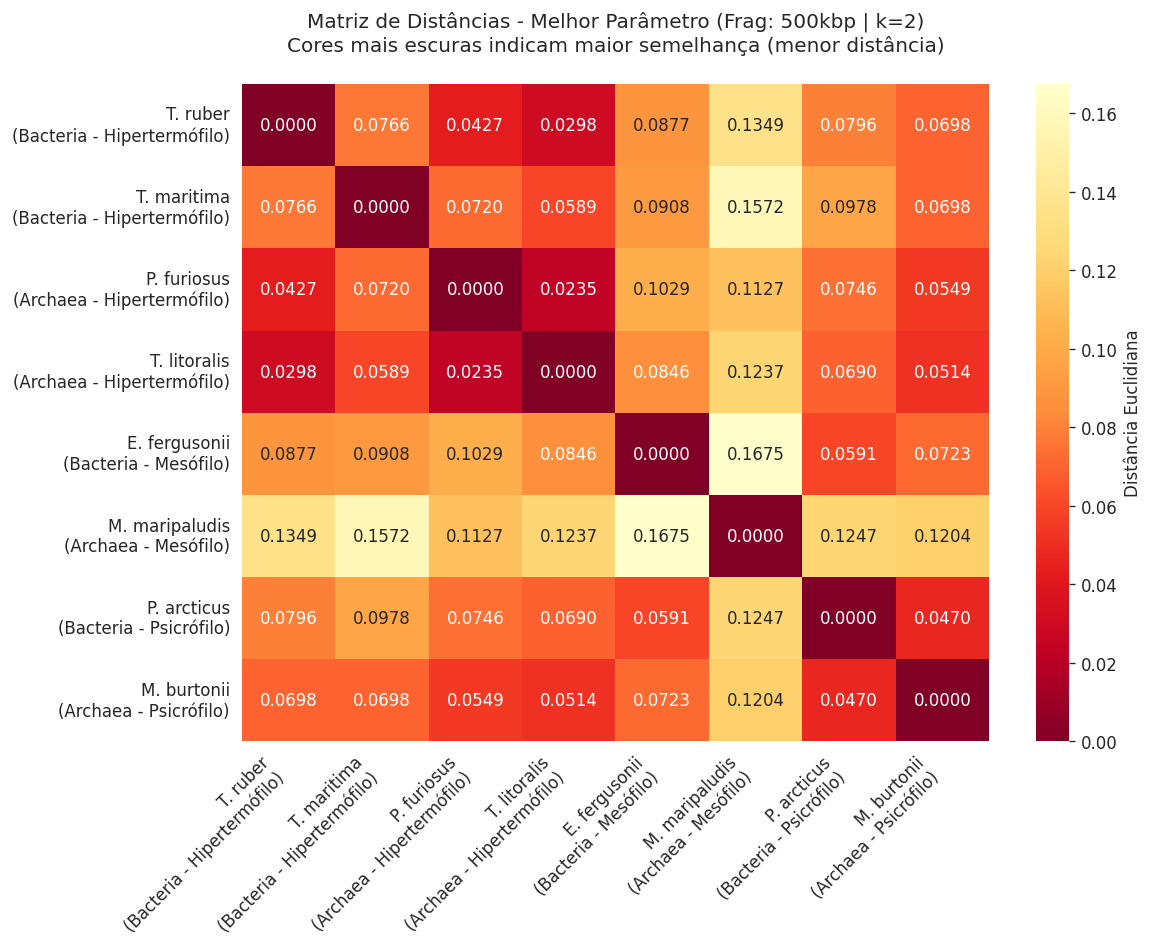


Heatmap salvo em: resultados/analise_numerica/heatmap_melhor_frag500kbp_k2.png


In [3]:
# Configurações visuais
plt.rcParams['figure.dpi'] = 120

tamanhos_frag = ["500kbp", "1000kbp", "1500kbp"]
valores_k = [1, 2, 3, 4, 5, 6, 7, 8]

resultados_metricas = []
melhor_score = float('inf')
melhor_parametro = None
melhor_matriz = None
melhor_df = None

print("Calculando distâncias para todos os parâmetros...\n")

for TAMANHO in tamanhos_frag:
    for K_VALUE in valores_k:
        csv_path = f'resultados/vetores_frag{TAMANHO}_k{K_VALUE}.csv'
        if not os.path.exists(csv_path):
            continue

        df = pd.read_csv(csv_path)

        # Isola apenas as colunas dos k-mers e normaliza para frequência relativa
        kmer_cols = df.columns[3:]
        vetores = df[kmer_cols].values
        vetores_norm = vetores / vetores.sum(axis=1, keepdims=True)

        # Calcula a matriz de distâncias Euclidianas entre todos os 8 organismos
        distancias = pdist(vetores_norm, metric='euclidean')
        matriz_dist = squareform(distancias)

        # Cria um DataFrame da matriz para facilitar a busca
        df_dist = pd.DataFrame(matriz_dist, index=df['organismo'], columns=df['organismo'])

        # Lógica da Métrica: Foco na T. ruber (Bactéria Hipertermófila)
        try:
            # 1. Distância para Archaeas do MESMO ambiente (Convergência)
            dist_env_pf = df_dist.loc['T. ruber', 'P. furiosus']
            dist_env_tl = df_dist.loc['T. ruber', 'T. litoralis']
            media_dist_ambiente = (dist_env_pf + dist_env_tl) / 2

            # 2. Distância para Bactérias de OUTROS ambientes (Taxonomia)
            dist_tax_ef = df_dist.loc['T. ruber', 'E. fergusonii'] # Mesófilo
            dist_tax_pa = df_dist.loc['T. ruber', 'P. arcticus']   # Psicrófilo
            media_dist_taxonomia = (dist_tax_ef + dist_tax_pa) / 2

            # Razão: (Distância Ambiente / Distância Taxonomia)
            # Menor que 1 significa que ela é mais parecida com as Archaeas do que com as Bactérias!
            razao = media_dist_ambiente / media_dist_taxonomia

            resultados_metricas.append({
                'Tamanho': TAMANHO,
                'K': K_VALUE,
                'Dist_Ambiente': media_dist_ambiente,
                'Dist_Taxonomia': media_dist_taxonomia,
                'Razao_Score': razao
            })

            # Guarda o melhor resultado (menor razão)
            if razao < melhor_score:
                melhor_score = razao
                melhor_parametro = (TAMANHO, K_VALUE)
                melhor_matriz = df_dist
                melhor_df = df

        except KeyError:
            # Caso algum organismo falte no CSV
            continue

# Converte resultados para DataFrame e ordena do melhor pro pior score
df_resultados = pd.DataFrame(resultados_metricas)
df_resultados = df_resultados.sort_values('Razao_Score').reset_index(drop=True)

print("RANKING DOS MELHORES PARÂMETROS (Menor Score é melhor):")
print(df_resultados.head(10).to_string())

# ==========================================
# PLOT DO HEATMAP PARA O MELHOR PARÂMETRO
# ==========================================
print(f"\nGerando Heatmap para o melhor parâmetro: {melhor_parametro[0]}, k={melhor_parametro[1]}")

# Ajustando os rótulos para mostrar "Nome (Domínio - Ambiente)" no Heatmap
rotulos = []
for org in melhor_matriz.index:
    meta = melhor_df[melhor_df['organismo'] == org].iloc[0]
    rotulos.append(f"{org}\n({meta['dominio']} - {meta['ambiente']})")

melhor_matriz.index = rotulos
melhor_matriz.columns = rotulos

plt.figure(figsize=(10, 8))
sns.heatmap(melhor_matriz, annot=True, fmt=".4f", cmap="YlOrRd_r", cbar_kws={'label': 'Distância Euclidiana'})
plt.title(f"Matriz de Distâncias - Melhor Parâmetro (Frag: {melhor_parametro[0]} | k={melhor_parametro[1]})\nCores mais escuras indicam maior semelhança (menor distância)", pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Salva o Heatmap
os.makedirs('resultados/analise_numerica', exist_ok=True)
caminho_heatmap = f'resultados/analise_numerica/heatmap_melhor_frag{melhor_parametro[0]}_k{melhor_parametro[1]}.png'
plt.savefig(caminho_heatmap)
plt.show()

print(f"\nHeatmap salvo em: {caminho_heatmap}")

In [4]:

pares_distancias = []

organismos = list(melhor_matriz.index)

for i in range(len(organismos)):
    for j in range(i + 1, len(organismos)):

        org1 = organismos[i]
        org2 = organismos[j]

        distancia = melhor_matriz.loc[org1, org2]

        pares_distancias.append({
            'Organismo 1': org1,
            'Organismo 2': org2,
            'Distância': distancia
        })

df_pares = pd.DataFrame(pares_distancias)

df_pares = df_pares.sort_values('Distância').reset_index(drop=True)

print(df_pares.to_string(index=False))

                             Organismo 1                              Organismo 2  Distância
 P. furiosus\n(Archaea - Hipertermófilo) T. litoralis\n(Archaea - Hipertermófilo)   0.023550
   T. ruber\n(Bacteria - Hipertermófilo) T. litoralis\n(Archaea - Hipertermófilo)   0.029766
   T. ruber\n(Bacteria - Hipertermófilo)  P. furiosus\n(Archaea - Hipertermófilo)   0.042693
    P. arcticus\n(Bacteria - Psicrófilo)      M. burtonii\n(Archaea - Psicrófilo)   0.046983
T. litoralis\n(Archaea - Hipertermófilo)      M. burtonii\n(Archaea - Psicrófilo)   0.051426
 P. furiosus\n(Archaea - Hipertermófilo)      M. burtonii\n(Archaea - Psicrófilo)   0.054922
T. maritima\n(Bacteria - Hipertermófilo) T. litoralis\n(Archaea - Hipertermófilo)   0.058897
    E. fergusonii\n(Bacteria - Mesófilo)     P. arcticus\n(Bacteria - Psicrófilo)   0.059086
T. litoralis\n(Archaea - Hipertermófilo)     P. arcticus\n(Bacteria - Psicrófilo)   0.069044
   T. ruber\n(Bacteria - Hipertermófilo)      M. burtonii\n(Archaea - 

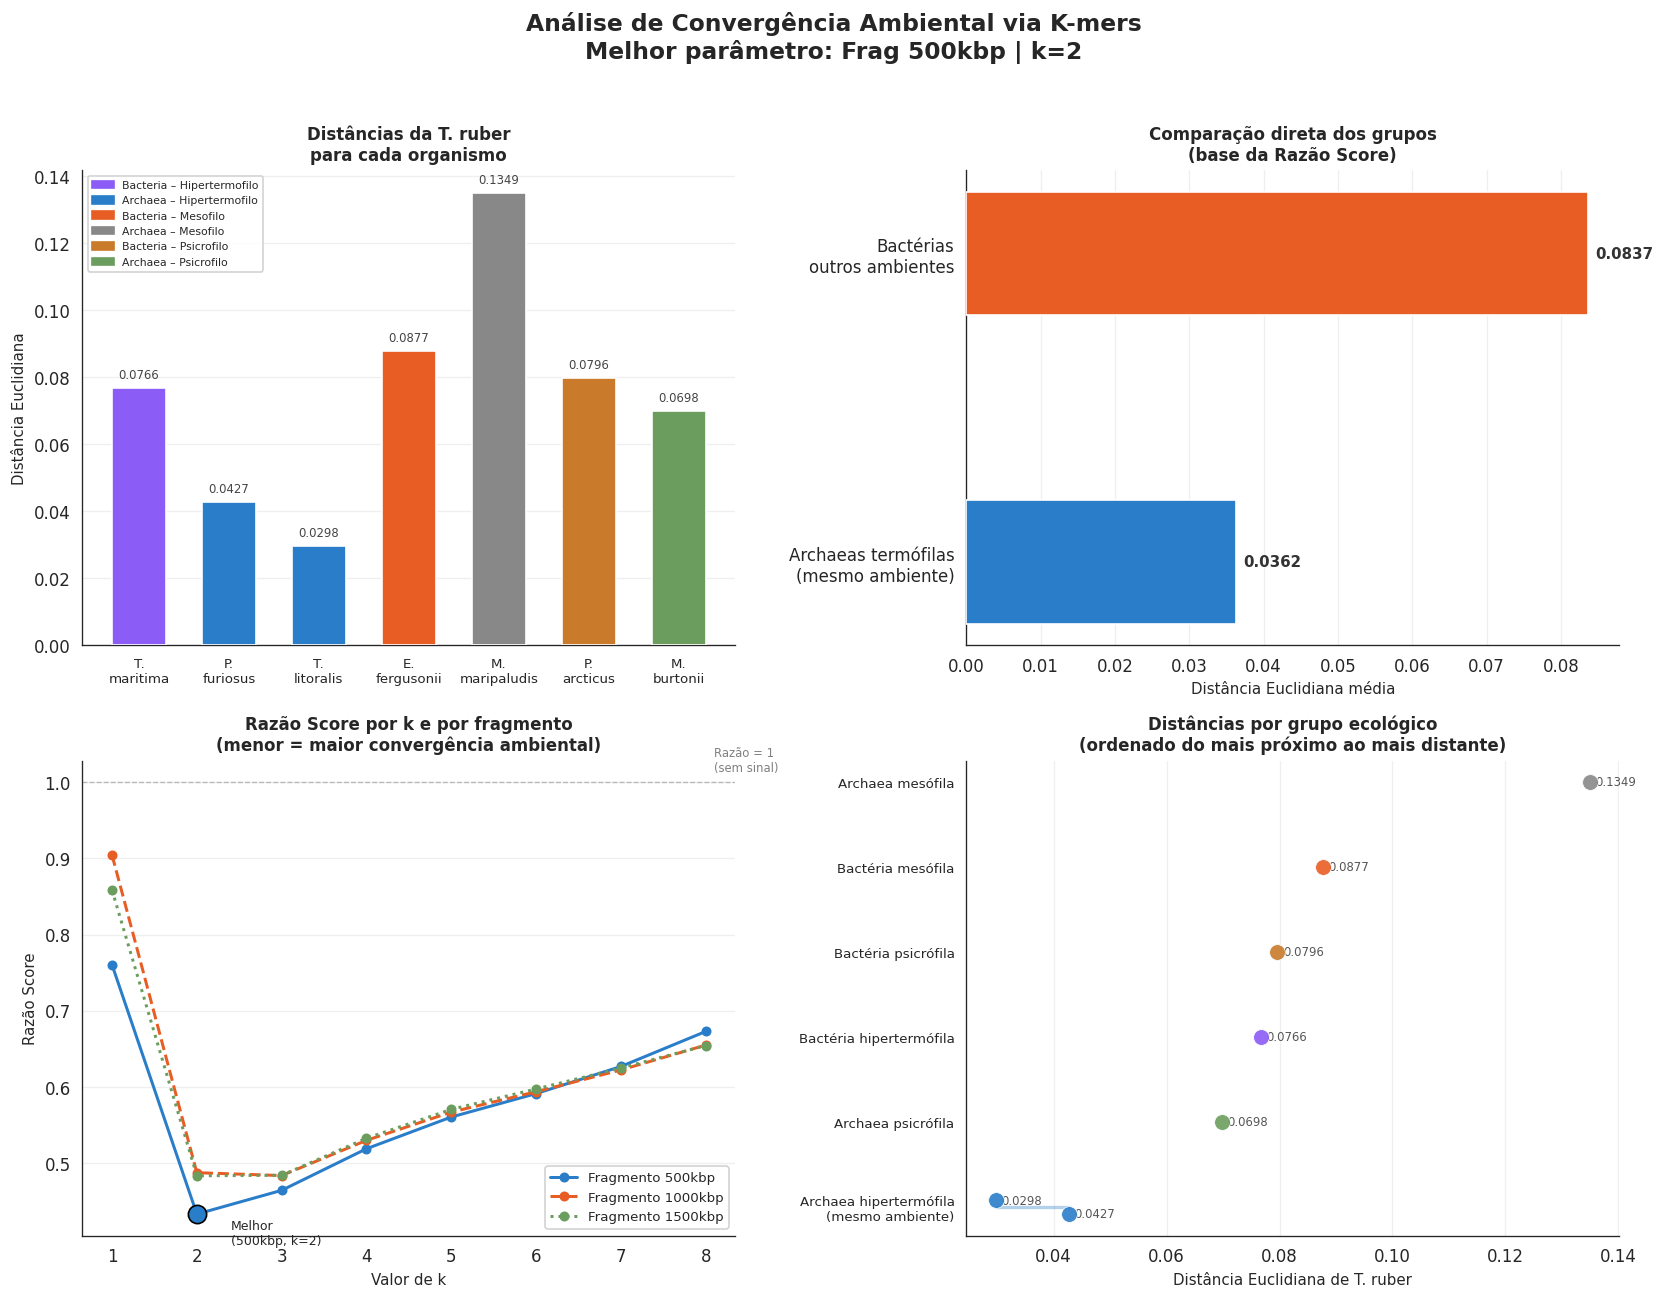


Gráficos complementares salvos em: resultados/analise_numerica/graficos_complementares_frag500kbp_k2.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


CORES_GRUPO = {
    ('Bacteria', 'Hipertermofilo'):  '#8B5CF6',
    ('Archaea',  'Hipertermofilo'):  '#2A7DC9',
    ('Bacteria', 'Mesofilo'):        '#E85D24',
    ('Archaea',  'Mesofilo'):        '#888888',
    ('Bacteria', 'Psicrofilo'):      '#C97A2A',
    ('Archaea',  'Psicrofilo'):      '#6B9E5E',
}

CORES_FRAG = {
    '500kbp':  ('#2A7DC9', '-'),
    '1000kbp': ('#E85D24', '--'),
    '1500kbp': ('#6B9E5E', ':'),
}

def cor_do_organismo(nome, df):
    """Retorna a cor de um organismo baseado no domínio e ambiente."""
    row = df[df['organismo'] == nome].iloc[0]
    dominio  = row['dominio'].strip()
    ambiente = row['ambiente'].strip()
    # Normaliza acentos comuns
    ambiente = (ambiente
        .replace('é', 'e').replace('ó', 'o')
        .replace('í', 'i').replace('ô', 'o')
        .replace('É', 'E').replace('Ó', 'O'))
    return CORES_GRUPO.get((dominio, ambiente), '#aaaaaa')


df_base = melhor_df.copy()
kmer_cols = df_base.columns[3:]
vetores = df_base[kmer_cols].values
vetores_norm = vetores / vetores.sum(axis=1, keepdims=True)
from scipy.spatial.distance import pdist, squareform
matriz_limpa = pd.DataFrame(
    squareform(pdist(vetores_norm, metric='euclidean')),
    index=df_base['organismo'],
    columns=df_base['organismo']
)

# Organismos (todos exceto T. ruber)
orgs = [o for o in matriz_limpa.index if o != 'T. ruber']
dists = [matriz_limpa.loc['T. ruber', o] for o in orgs]
cores = [cor_do_organismo(o, df_base) for o in orgs]

# Grupos para a razão
dist_ambiente  = (matriz_limpa.loc['T. ruber', 'P. furiosus'] +
                  matriz_limpa.loc['T. ruber', 'T. litoralis']) / 2
dist_taxonomia = (matriz_limpa.loc['T. ruber', 'E. fergusonii'] +
                  matriz_limpa.loc['T. ruber', 'P. arcticus']) / 2
razao_final = dist_ambiente / dist_taxonomia


fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(
    f'Análise de Convergência Ambiental via K-mers\n'
    f'Melhor parâmetro: Frag {melhor_parametro[0]} | k={melhor_parametro[1]}',
    fontsize=14, fontweight='bold', y=0.98
)

ax1, ax2, ax3, ax4 = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

for ax in [ax1, ax2, ax3, ax4]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# GRÁFICO 1 — Barras: distâncias da T. ruber
bars = ax1.bar(range(len(orgs)), dists, color=cores, width=0.6, zorder=3)

ax1.set_xticks(range(len(orgs)))
ax1.set_xticklabels([o.replace('. ', '.\n') for o in orgs], fontsize=8)
ax1.set_ylabel('Distância Euclidiana', fontsize=9)
ax1.set_title('Distâncias da T. ruber\npara cada organismo', fontsize=10, fontweight='bold')
ax1.yaxis.grid(True, alpha=0.3, zorder=0)
ax1.set_axisbelow(True)

for bar, val in zip(bars, dists):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{val:.4f}', ha='center', va='bottom', fontsize=7, color='#444'
    )

# Legenda do gráfico 1
patches = [mpatches.Patch(color=c, label=f'{d[0]} – {d[1]}')
           for d, c in CORES_GRUPO.items()]
ax1.legend(handles=patches, fontsize=6.5, loc='upper left',
           framealpha=0.85, ncol=1)


# GRÁFICO 2 — Barras horizontais: comparação dos dois grupos
grupos_label = ['Archaeas termófilas\n(mesmo ambiente)', 'Bactérias\noutros ambientes']
grupos_val   = [dist_ambiente, dist_taxonomia]
cores_grupos = ['#2A7DC9', '#E85D24']

hbars = ax2.barh(grupos_label, grupos_val, color=cores_grupos,
                 height=0.4, zorder=3)
ax2.xaxis.grid(True, alpha=0.3, zorder=0)
ax2.set_axisbelow(True)
ax2.set_xlabel('Distância Euclidiana média', fontsize=9)
ax2.set_title('Comparação direta dos grupos\n(base da Razão Score)', fontsize=10, fontweight='bold')

for bar, val in zip(hbars, grupos_val):
    ax2.text(
        val + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}', va='center', fontsize=9, fontweight='bold', color='#333'
    )


# GRÁFICO 3 — Linhas: Razão Score por k e por fragmento
tamanhos_frag_lista = ["500kbp", "1000kbp", "1500kbp"]

for tamanho in tamanhos_frag_lista:
    sub = (df_resultados[df_resultados['Tamanho'] == tamanho]
           .sort_values('K'))
    if sub.empty:
        continue
    cor, estilo = CORES_FRAG[tamanho]
    ax3.plot(
        sub['K'], sub['Razao_Score'],
        color=cor, linestyle=estilo,
        marker='o', markersize=5,
        linewidth=1.8,
        label=f'Fragmento {tamanho}'
    )

# Linha de referência razão = 1
ax3.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax3.text(
    df_resultados['K'].max() + 0.1, 1.01,
    'Razão = 1\n(sem sinal)', fontsize=7, color='gray', va='bottom'
)

# Marca o melhor ponto
melhor_row = df_resultados.sort_values('Razao_Score').iloc[0]
cor_melhor, _ = CORES_FRAG.get(melhor_row['Tamanho'], ('#333', '-'))
ax3.scatter(
    melhor_row['K'], melhor_row['Razao_Score'],
    s=120, zorder=5,
    color=cor_melhor, edgecolors='black', linewidths=1
)
ax3.annotate(
    f"Melhor\n({melhor_row['Tamanho']}, k={int(melhor_row['K'])})",
    xy=(melhor_row['K'], melhor_row['Razao_Score']),
    xytext=(melhor_row['K'] + 0.4, melhor_row['Razao_Score'] - 0.04),
    fontsize=7.5,
    arrowprops=dict(arrowstyle='->', lw=0.8)
)

ax3.set_xlabel('Valor de k', fontsize=9)
ax3.set_ylabel('Razão Score', fontsize=9)
ax3.set_title(
    'Razão Score por k e por fragmento\n(menor = maior convergência ambiental)',
    fontsize=10, fontweight='bold'
)
ax3.set_xticks(sorted(df_resultados['K'].unique()))
ax3.yaxis.grid(True, alpha=0.3)
ax3.set_axisbelow(True)
ax3.legend(fontsize=8, framealpha=0.85)

# GRÁFICO 4 — Dot plot: distâncias por grupo ecológico
mapeamento_grupo = {
    'T. maritima':    ('Bactéria hipertermófila',           '#8B5CF6'),
    'P. furiosus':    ('Archaea hipertermófila\n(mesmo ambiente)', '#2A7DC9'),
    'T. litoralis':   ('Archaea hipertermófila\n(mesmo ambiente)', '#2A7DC9'),
    'E. fergusonii':  ('Bactéria mesófila',                 '#E85D24'),
    'M. maripaludis': ('Archaea mesófila',                  '#888888'),
    'P. arcticus':    ('Bactéria psicrófila',               '#C97A2A'),
    'M. burtonii':    ('Archaea psicrófila',                '#6B9E5E'),
}

# Agrupa os valores por categoria
grupo_vals  = {}
grupo_cores = {}
for org, dist in zip(orgs, dists):
    if org in mapeamento_grupo:
        grp, cor = mapeamento_grupo[org]
        grupo_vals.setdefault(grp, []).append(dist)
        grupo_cores[grp] = cor

# Ordem de exibição (do mais próximo ao mais distante em média)
grupos_ord = sorted(grupo_vals.keys(),
                    key=lambda g: np.mean(grupo_vals[g]))

for i, grp in enumerate(grupos_ord):
    vals = grupo_vals[grp]
    cor  = grupo_cores[grp]

    # Jitter vertical para grupos com 2+ pontos
    jitter = np.linspace(-0.08, 0.08, len(vals)) if len(vals) > 1 else [0]

    for j, v in zip(jitter, vals):
        ax4.scatter(v, i + j, color=cor, s=90, zorder=4, alpha=0.9,
                    edgecolors='white', linewidths=0.5)

    # Linha de extensão entre os pontos do mesmo grupo
    if len(vals) > 1:
        ax4.plot([min(vals), max(vals)], [i, i],
                 color=cor, linewidth=2, alpha=0.35, zorder=3)

    # Valor anotado ao lado de cada ponto
    for j, v in zip(jitter, vals):
        ax4.text(v + 0.001, i + j, f'{v:.4f}',
                 va='center', fontsize=7, color='#555')

ax4.set_yticks(range(len(grupos_ord)))
ax4.set_yticklabels(grupos_ord, fontsize=8)
ax4.set_xlabel('Distância Euclidiana de T. ruber', fontsize=9)
ax4.set_title('Distâncias por grupo ecológico\n(ordenado do mais próximo ao mais distante)',
              fontsize=10, fontweight='bold')
ax4.xaxis.grid(True, alpha=0.3)
ax4.set_axisbelow(True)

# ------------------------------------------
# SALVA
# ------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])

os.makedirs('resultados/analise_numerica', exist_ok=True)
caminho_graficos = (
    f'resultados/analise_numerica/'
    f'graficos_complementares_frag{melhor_parametro[0]}_k{melhor_parametro[1]}.png'
)
plt.savefig(caminho_graficos, bbox_inches='tight', dpi=150)
plt.show()

print(f"\nGráficos complementares salvos em: {caminho_graficos}")